Library

In [1]:
import pandas as pd
import re
import string
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

Import Data

In [2]:
df = pd.read_excel("dataset.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           350 non-null    object
 1   name            350 non-null    object
 2   stars           350 non-null    int64 
 3   text            350 non-null    object
 4   label_sentimen  350 non-null    object
dtypes: int64(1), object(4)
memory usage: 13.8+ KB


Preprocessing

In [3]:
slangwords_list = pd.read_csv('./slang/slang.csv')
slangwords_custom = pd.read_csv('./slang/slang-custom.csv')

slangwords_list.update(slangwords_custom)
slangwords_list = slangwords_list[['slang', 'formal']]
slang_dict = dict(zip(slangwords_list['slang'], slangwords_list['formal']))

In [4]:
listStopwords = set(stopwords.words('indonesian'))
listStopwords.update(stopwords.words('english'))
custom_stopwords = {'iya','yaa','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"}
negative_words = {'nggak', 'ngga', 'gak', 'ga', 'gk', 'tidak', 'tdk', 'tak'}
listStopwords.update(custom_stopwords)
listStopwords -= negative_words

In [5]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
 
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text
 
def casefoldingText(text):
    text = text.lower()
    return text
 
def tokenizingText(text):
    text = word_tokenize(text)
    return text

def filteringText(text): # Drop stopwords
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text
 
def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
 
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text
 
def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

def fix_slangwords(text):
    words = text.split()
    fixed_words = []
 
    for word in words:
        translate = slang_dict.get(word.lower(), word) 
        fixed_words.append(translate)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [6]:
df['text_clean'] = df['text'].astype(str).apply(cleaningText)
df['text_casefoldingText'] = df['text_clean'].apply(casefoldingText)
df['text_slangwords'] = df['text_casefoldingText'].apply(fix_slangwords)
df['text_stemming'] = df['text_slangwords'].apply(stemmingText)
df['text_tokenizingText'] = df['text_stemming'].apply(tokenizingText)
df['text_stopword'] = df['text_tokenizingText'].apply(filteringText)
df['text_final'] = df['text_stopword'].apply(toSentence)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   title                 350 non-null    object
 1   name                  350 non-null    object
 2   stars                 350 non-null    int64 
 3   text                  350 non-null    object
 4   label_sentimen        350 non-null    object
 5   text_clean            350 non-null    object
 6   text_casefoldingText  350 non-null    object
 7   text_slangwords       350 non-null    object
 8   text_stemming         350 non-null    object
 9   text_tokenizingText   350 non-null    object
 10  text_stopword         350 non-null    object
 11  text_final            350 non-null    object
dtypes: int64(1), object(11)
memory usage: 32.9+ KB


In [8]:
df[['text', 'text_final']]
# df.head()

,text,text_final
0,Joss terminalnya makasih,bagus terminal terima kasih
1,Sangat mengecewakan banyak oknum pungli .. mem...,kecewa oknum pungli paksa hadap tumpang
2,Lumayan bagus dan cukup tertata\nLoket telah d...,lumayan bagus tata loket sedia bagus deret cal...
3,Terminal Purwokerto ini cukup luas sudah banya...,terminal purwokerto luas bangun maju lobby gra...
4,terminal penuh kenangan dengan almarhum mbah k...,terminal penuh kenang almarhum mbah kakung lik...
...,...,...
345,"dekat, strategis, nyaman, teduh, banyak transp...",strategis nyaman teduh transportasi murah murah
346,Bua Trans Jateng Sangat membantu perjalanan di...,bua trans jateng bantu jalan lintas banyumas p...
347,"Halte yang mudah ditemukan, jarena tepat dipin...",halte mudah temu jarena pinggir jalan pasar po...
348,Dekat dengan pasar pon. Pas di terminal trans ...,pasar pon terminal trans banyumas


In [9]:
df.to_csv('data_clean.csv')

5. Penyeimbangan Data Menggunakan SMOTE & Modeling Naive Bayes



In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, df['label_sentimen'])

nb_model = MultinomialNB()
nb_model.fit(X_smote, y_smote)
print("Model berhasil dilatih!")

print("--- Pembuktian Data Seimbang (Sebelum vs Sesudah SMOTE) ---")
print("Jumlah data awal:", y.value_counts().to_dict())
print("Jumlah data setelah SMOTE:", pd.Series(y_smote).value_counts().to_dict())

# Kita tampilkan dalam tabel agar lebih rapi
df_seimbang = pd.DataFrame({
    'Sentimen': ['Positif', 'Negatif'],
    'Jumlah Awal': [y.value_counts()['Positif'], y.value_counts()['Negatif']],
    'Jumlah Setelah SMOTE': [pd.Series(y_smote).value_counts()['Positif'], pd.Series(y_smote).value_counts()['Negatif']]
})
display(df_seimbang)

NameError: name 'X' is not defined

6.  Hasil Akhir

In [ ]:
# Cell 6: Prediksi & Simpan ke Excel
df['prediksi_ai'] = nb_model.predict(X)
df.to_excel(writer, sheet_name='4_Hasil_Akhir', index=False)
writer.close()

print("--- Tabel 4: Hasil Prediksi Akhir ---")
display(df[['text', 'label_sentimen', 'prediksi_ai']].head(10))

--- Tabel 4: Hasil Prediksi Akhir ---


,text,label_sentimen,prediksi_ai
0,Joss terminalnya makasih,Positif,Positif
1,Sangat mengecewakan banyak oknum pungli .. mem...,Negatif,Negatif
2,Lumayan bagus dan cukup tertata\nLoket telah d...,Positif,Positif
3,Terminal Purwokerto ini cukup luas sudah banya...,Positif,Positif
4,terminal penuh kenangan dengan almarhum mbah k...,Positif,Positif
5,Bersih dan nyaman,Positif,Positif
6,Menurut saya sangat buruk perhatian terhadap s...,Negatif,Negatif
7,Nunggu nya lama banget dari jam 7 sampe jam 12,Negatif,Negatif
8,"tempatnya panas gk ada AC gk ada kipas, kotor ...",Negatif,Negatif
9,Bagus banget...bersih rapi aman terkendali,Positif,Positif


7. Bar Chart Klasifikasi Model

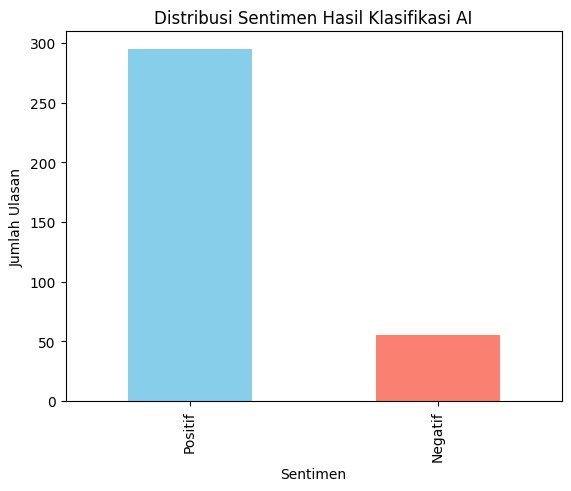

In [ ]:
import matplotlib.pyplot as plt

sentimen_counts = df['prediksi_ai'].value_counts()
sentimen_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribusi Sentimen Hasil Klasifikasi AI')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()